In [74]:
# Capstone Project: EDA and Predictive Modeling for Stock Returns

## Predicting Short-Term Stock Returns Using Technical and Fundamental Indicators

### Research Question
#Can short-term to medium-term stock returns be predicted using historical price behavior, trading volume patterns, and company fundamentals?

### Project Objective
#This notebook builds a complete end-to-end forecasting pipeline using:
#- Exploratory data analysis (EDA)
#- Feature engineering from price and volume data
#- Fundamental company variables
#- Linear benchmark models
#- Tree-based and distance-based machine learning models
#- Time-series forecasting models (ARIMA and SARIMA)

### Final Deliverable
#The goal is to compare multiple modeling approaches on the same financial prediction task and determine whether any method offers a meaningful improvement in out-of-sample forecasting performance.


In [75]:
# Install any external libraries needed for this notebook.
# yfinance is used to download market data from Yahoo Finance.
# statsmodels is used for ARIMA and SARIMA time-series models.

!pip install yfinance statsmodels -q


In [76]:
# ===============================
# DATA MANIPULATION
# ===============================
import yfinance as yf
import pandas as pd
import numpy as np

# ===============================
# VISUALIZATION
# ===============================
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# MACHINE LEARNING
# ===============================
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# ===============================
# TIME SERIES MODELING
# ===============================
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ===============================
# GENERAL SETTINGS
# ===============================
import warnings
warnings.filterwarnings("ignore")

# Professional plot styling for a cleaner final report.
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

# Set a seed so tree-based and neighbor-based model results are reproducible.
RANDOM_STATE = 42

print("All libraries successfully imported.")


All libraries successfully imported.


In [77]:
# Define diversified large-cap stock 
tickers = [
    "AAPL","MSFT","NVDA","GOOGL","META","AMZN","ADBE","CRM",
    "JPM","BAC","GS","MS","WFC","C","BLK",
    "WMT","COST","HD","LOW","MCD","NKE",
    "CAT","DE","HON","GE","BA",
    "JNJ","UNH","PFE","MRK",
    "XOM","CVX","COP"
]

start_date = "2023-01-01"
end_date = "2025-12-31"

print("Downloading price data from Yahoo Finance")

price_data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    group_by="ticker",
    auto_adjust=True,
    progress=False
)

print("Download complete.")

Download complete.


In [78]:
frames = []

print("Beginning feature engineering")

for ticker in tickers:
    
    df = price_data[ticker].copy()
    df["ticker"] = ticker
    
    # Daily return
    df["return_1d"] = df["Close"].pct_change()
    
    # 5-day return
    df["return_5d"] = df["Close"].pct_change(5)
    
    # Rolling volatility
    df["vol_10d"] = df["return_1d"].rolling(10).std()
    df["vol_20d"] = df["return_1d"].rolling(20).std()
    
    # Volume anomaly (z-score)
    df["volume_z"] = (
        df["Volume"] - df["Volume"].rolling(20).mean()
    ) / df["Volume"].rolling(20).std()
    
    # Momentum
    df["momentum_10d"] = df["Close"] / df["Close"].shift(10) - 1
    
    # Forward 5-day return (prediction target)
    df["target_5d"] = df["Close"].pct_change(5).shift(-5)
    
    frames.append(df.reset_index())

price_features = pd.concat(frames, ignore_index=True)

print("Feature engineering complete.")
print("Current dataset shape:", price_features.shape)

Beginning feature engineering
Feature engineering complete.
Current dataset shape: (24783, 14)


In [79]:
print("Retrieving fundamental data")

fundamental_rows = []

for ticker in tickers:
    info = yf.Ticker(ticker).info
    
    fundamental_rows.append({
        "ticker": ticker,
        "market_cap": info.get("marketCap"),
        "pe_ratio": info.get("trailingPE"),
        "forward_pe": info.get("forwardPE"),
        "price_to_book": info.get("priceToBook"),
        "beta": info.get("beta"),
        "sector": info.get("sector")
    })

fundamentals = pd.DataFrame(fundamental_rows)

print("Fundamental data collected.")

Retrieving fundamental data
Fundamental data collected.


In [80]:
print("Merging price and fundamental data")

data = price_features.merge(fundamentals, on="ticker", how="left")

# Remove duplicates
duplicates = data.duplicated().sum()
print("Duplicate rows detected:", duplicates)
data = data.drop_duplicates()

# Drop rows missing key engineered values
data = data.dropna(subset=[
    "return_1d","return_5d","vol_10d",
    "vol_20d","volume_z","momentum_10d",
    "target_5d"
])

print("Final cleaned dataset shape:", data.shape)

Merging price and fundamental data
Duplicate rows detected: 0
Final cleaned dataset shape: (23958, 20)


Visualizing distribution of target variable


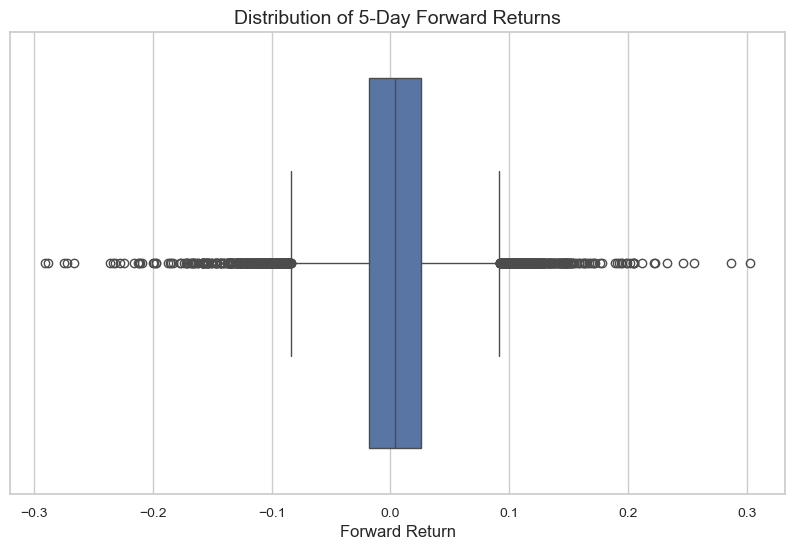

Outliers capped at 1st and 99th percentiles.


In [81]:
print("Visualizing distribution of target variable")

plt.figure()
sns.boxplot(x=data["target_5d"])
plt.title("Distribution of 5-Day Forward Returns")
plt.xlabel("Forward Return")
plt.show()

# Winsorize extreme values
lower = data["target_5d"].quantile(0.01)
upper = data["target_5d"].quantile(0.99)

data["target_5d"] = np.clip(data["target_5d"], lower, upper)

print("Outliers capped at 1st and 99th percentiles.")

Generating correlation heatmap


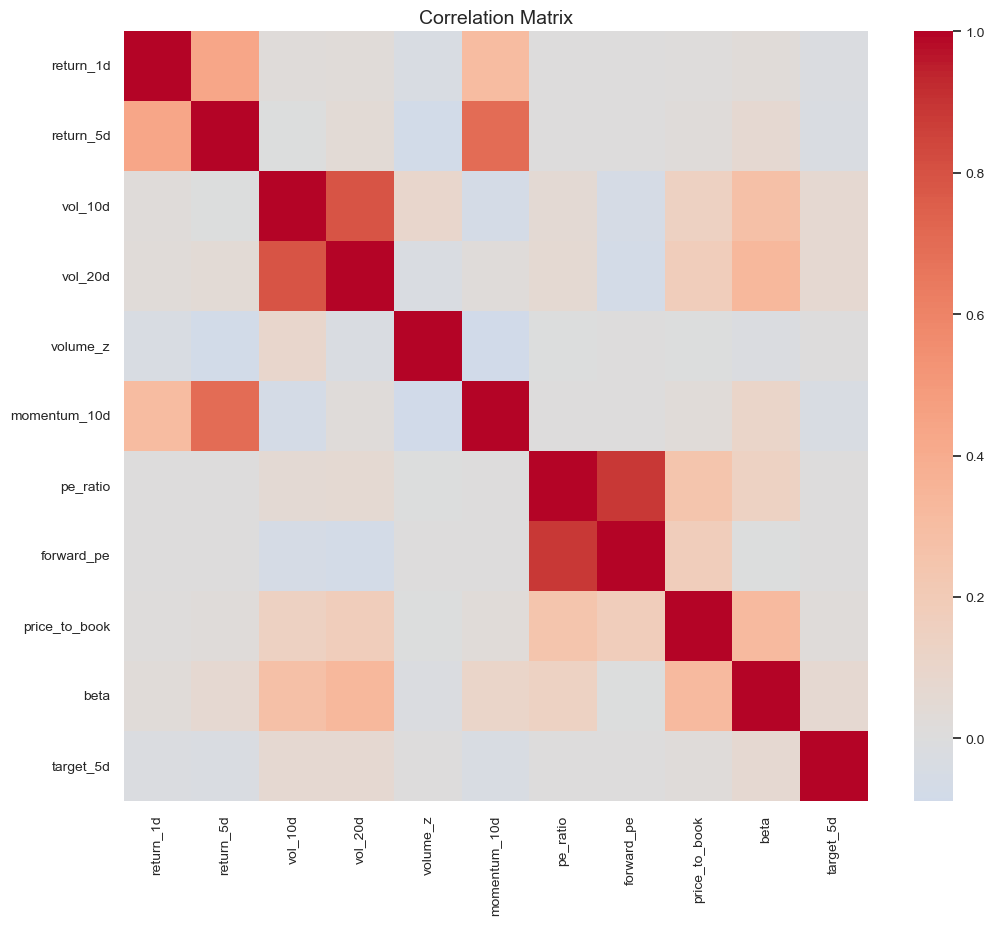

In [82]:
feature_cols = [
    "return_1d","return_5d",
    "vol_10d","vol_20d",
    "volume_z","momentum_10d",
    "pe_ratio","forward_pe",
    "price_to_book","beta"
]

print("Generating correlation heatmap")

plt.figure(figsize=(12,10))
sns.heatmap(
    data[feature_cols + ["target_5d"]].corr(),
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix")
plt.show()

Performing PCA on technical indicators


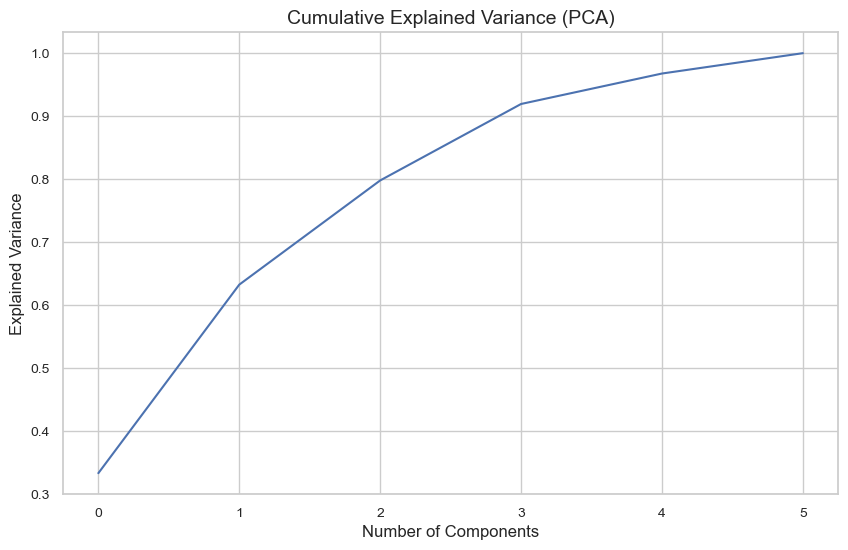

Total variance explained by first 2 components: 0.632409295462774


In [83]:
print("Performing PCA on technical indicators")

tech_cols = [
    "return_1d","return_5d",
    "vol_10d","vol_20d",
    "volume_z","momentum_10d"
]

scaler = StandardScaler()
X_tech_scaled = scaler.fit_transform(data[tech_cols])

pca = PCA()
pca.fit(X_tech_scaled)

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.title("Cumulative Explained Variance (PCA)")
plt.xlabel("Number of Components")
plt.ylabel("Explained Variance")
plt.show()

print("Total variance explained by first 2 components:",
      np.sum(pca.explained_variance_ratio_[:2]))

In [84]:
print("Splitting data into training and testing sets (time-based split)")

# Sort observations by date so that the model only learns from past data
# and is evaluated on future data.
data = data.sort_values("Date")

# All observations before the split date are used for training.
# All observations on or after the split date are treated as unseen test data.
split_date = "2025-01-01"

train = data[data["Date"] < split_date].copy()
test = data[data["Date"] >= split_date].copy()

X_train = train[feature_cols]
y_train = train["target_5d"]

X_test = test[feature_cols]
y_test = test["target_5d"]

# Scale features for models that are sensitive to feature magnitude
# (especially OLS with regularization and KNN).
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("Training period:", train["Date"].min(), "to", train["Date"].max())
print("Testing period:", test["Date"].min(), "to", test["Date"].max())


Splitting data into training and testing sets (time-based split)
Training set size: (15906, 10)
Testing set size: (8052, 10)
Training period: 2023-02-01 00:00:00 to 2024-12-31 00:00:00
Testing period: 2025-01-02 00:00:00 to 2025-12-22 00:00:00


In [85]:
print("Two evaluation metrics are used:\n"
      "\n"
      "1. Mean Squared Error (MSE)\n"
      "2. R-squared (R²)\n"
      "\n"
      "MSE is selected as the primary evaluation metric because:\n"
      "\n"
      "- It penalizes larger prediction errors more heavily.\n"
      "- It directly measures prediction accuracy in squared return space.\n"
      "- It is the standard loss function for regression models.\n"
      "\n"
      "R² is included as a complementary metric to measure the proportion of variance explained by the model.")

Two evaluation metrics are used:

1. Mean Squared Error (MSE)
2. R-squared (R²)

MSE is selected as the primary evaluation metric because:

- It penalizes larger prediction errors more heavily.
- It directly measures prediction accuracy in squared return space.
- It is the standard loss function for regression models.

R² is included as a complementary metric to measure the proportion of variance explained by the model.


In [86]:
print("Training baseline OLS model")

ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)

ols_preds = ols_model.predict(X_test_scaled)

ols_mse = mean_squared_error(y_test, ols_preds)
ols_r2 = r2_score(y_test, ols_preds)

print("OLS MSE:", ols_mse)
print("OLS R²:", ols_r2)

print("Ordinary Least Squares (OLS) regression is selected as the baseline model because:\n"
      "\n"
      "- It provides an interpretable linear benchmark.\n"
      "- It allows direct coefficient interpretation.\n"
      "- It establishes a performance floor before applying regularization.\n"
      "- It is the standard starting point for financial return modeling.\n"
      "\n")

Training baseline OLS model
OLS MSE: 0.001562238066860424
OLS R²: 0.0072494186946086
Ordinary Least Squares (OLS) regression is selected as the baseline model because:

- It provides an interpretable linear benchmark.
- It allows direct coefficient interpretation.
- It establishes a performance floor before applying regularization.
- It is the standard starting point for financial return modeling.




In [87]:
print("Training Ridge and Lasso with cross-validation")

# Candidate regularization strengths tested across a wide logarithmic range.
alphas = np.logspace(-4, 4, 50)

# Ridge shrinks coefficients smoothly but keeps all predictors.
ridge_model = RidgeCV(alphas=alphas, cv=5)
ridge_model.fit(X_train_scaled, y_train)

# Lasso can shrink some coefficients all the way to zero,
# which effectively performs feature selection.
lasso_model = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)

ridge_preds = ridge_model.predict(X_test_scaled)
lasso_preds = lasso_model.predict(X_test_scaled)

ridge_mse = mean_squared_error(y_test, ridge_preds)
ridge_r2 = r2_score(y_test, ridge_preds)

lasso_mse = mean_squared_error(y_test, lasso_preds)
lasso_r2 = r2_score(y_test, lasso_preds)

print("Selected Ridge alpha:", ridge_model.alpha_)
print("Selected Lasso alpha:", lasso_model.alpha_)
print("Ridge MSE:", ridge_mse)
print("Ridge R²:", ridge_r2)
print("Lasso MSE:", lasso_mse)
print("Lasso R²:", lasso_r2)


Training Ridge and Lasso with cross-validation
Selected Ridge alpha: 10000.0
Selected Lasso alpha: 0.0020235896477251557
Ridge MSE: 0.0015621291518024781
Ridge R²: 0.0073186306088374176
Lasso MSE: 0.0015724342887492597
Lasso R²: 0.0007700571798794353


In [88]:
# Cross-Validation for Ridge Regression
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(Ridge(), X_train, y_train, cv=5, scoring='neg_mean_squared_error')
print('Cross-Validated MSE:', -cv_scores.mean())

Cross-Validated MSE: 0.001231927973616965


In [89]:
# Grid Search for Ridge Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
param_grid = {'alpha': [0.01, 0.1, 1, 10]}
grid = GridSearchCV(Ridge(), param_grid, cv=5)
grid.fit(X_train, y_train)
print('Best Parameters:', grid.best_params_)

Best Parameters: {'alpha': 10}


In [90]:
print("Reviewing the linear model results before adding nonlinear models")

# At this point, only the linear specifications have been trained.
# Their final head-to-head comparison with Decision Tree and KNN will appear
# in the next modeling section so that all cross-sectional models are judged
# on the same test set and in the same charts.
linear_results = pd.DataFrame({
    "Model": ["OLS", "Ridge", "Lasso"],
    "MSE": [ols_mse, ridge_mse, lasso_mse],
    "R2": [ols_r2, ridge_r2, lasso_r2]
}).sort_values("MSE").reset_index(drop=True)

print(linear_results)
print(
    "These linear models establish the benchmark. "
    "The next section adds Decision Tree and KNN so all cross-sectional models "
    "can be compared together in one table and one set of charts."
)


Reviewing the linear model results before adding nonlinear models
   Model       MSE        R2
0  Ridge  0.001562  0.007319
1    OLS  0.001562  0.007249
2  Lasso  0.001572  0.000770
These linear models establish the benchmark. The next section adds Decision Tree and KNN so all cross-sectional models can be compared together in one table and one set of charts.


Analyzing coefficient stability
                    OLS     Ridge     Lasso
Feature                                    
return_1d     -0.000065 -0.000109 -0.000000
return_5d     -0.000577 -0.000376 -0.000000
vol_10d        0.001159  0.000748  0.000000
vol_20d        0.000615  0.000644  0.000000
volume_z      -0.000078 -0.000020  0.000000
momentum_10d  -0.000635 -0.000343 -0.000000
pe_ratio      -0.002799 -0.000247  0.000000
forward_pe     0.002876  0.000332  0.000000
price_to_book -0.000124  0.000106  0.000000
beta           0.002940  0.001589  0.001015


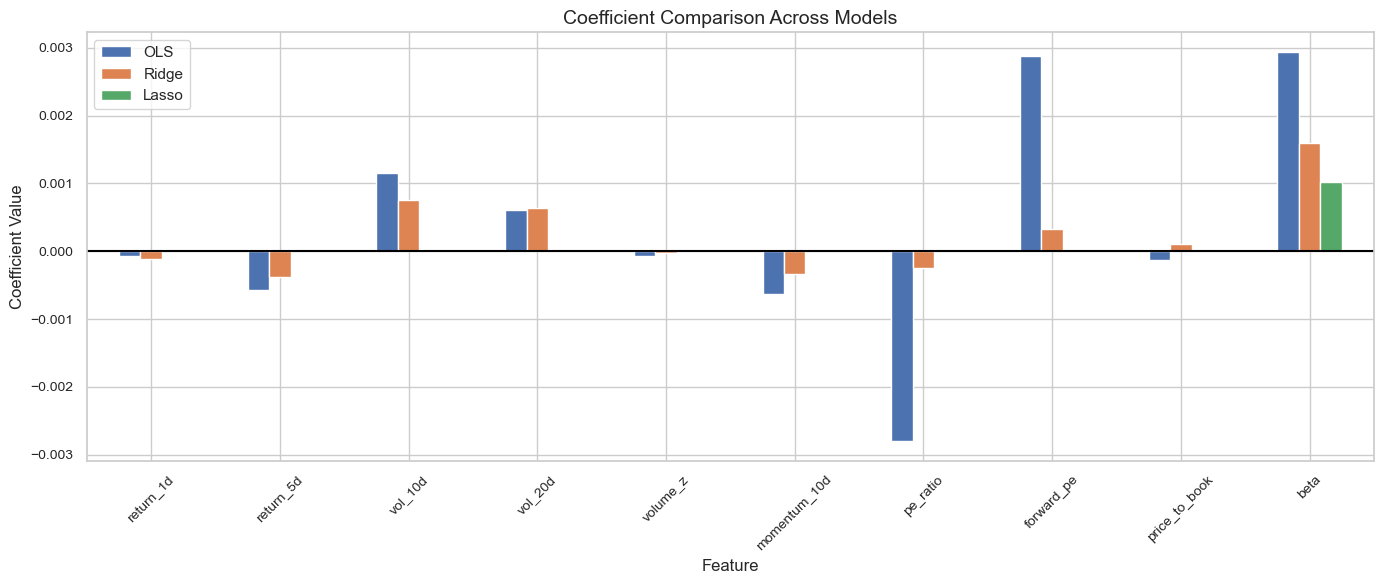

In [91]:
print("Analyzing coefficient stability")

coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "OLS": ols_model.coef_,
    "Ridge": ridge_model.coef_,
    "Lasso": lasso_model.coef_
}).set_index("Feature")

print(coef_df)

coef_df.plot(kind="bar", figsize=(14,6))
plt.axhline(0, color='black')
plt.title("Coefficient Comparison Across Models")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [92]:
print("Performing TimeSeriesSplit validation on Ridge")

# TimeSeriesSplit preserves ordering and is more appropriate than random CV
# for financial time series because future observations must never leak into training.
tscv = TimeSeriesSplit(n_splits=5)
tscv_mse = []

for train_idx, val_idx in tscv.split(X_train_scaled):
    X_t, X_v = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_t, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = Ridge(alpha=ridge_model.alpha_)
    model.fit(X_t, y_t)
    preds = model.predict(X_v)
    tscv_mse.append(mean_squared_error(y_v, preds))

print("Average TimeSeries CV MSE:", np.mean(tscv_mse))


Performing TimeSeriesSplit validation on Ridge
Average TimeSeries CV MSE: 0.001206921706263343


Training nonlinear machine learning models and comparing all cross-sectional models together
Best Decision Tree parameters: {'max_depth': 3, 'min_samples_leaf': 10, 'min_samples_split': 100}
Decision Tree MSE: 0.0015770503415612365
Decision Tree R²: -0.002163291590475236
Best KNN parameters: {'n_neighbors': 30, 'weights': 'uniform'}
KNN MSE: 0.0016310197173509294
KNN R²: -0.03645904351487994

Comparison of all cross-sectional models:
           Model             Model_Type       MSE        R2  MSE_Rank  \
0          Ridge  Regularized Linear ML  0.001562  0.007319         1   
1            OLS              Linear ML  0.001562  0.007249         2   
2          Lasso  Regularized Linear ML  0.001572  0.000770         3   
3  Decision Tree           Nonlinear ML  0.001577 -0.002163         4   
4            KNN           Nonlinear ML  0.001631 -0.036459         5   

   R2_Rank   MSE_vs_Best  R2_vs_Best  
0        1  0.000000e+00    0.000000  
1        2  1.089151e-07    0.000069  
2     

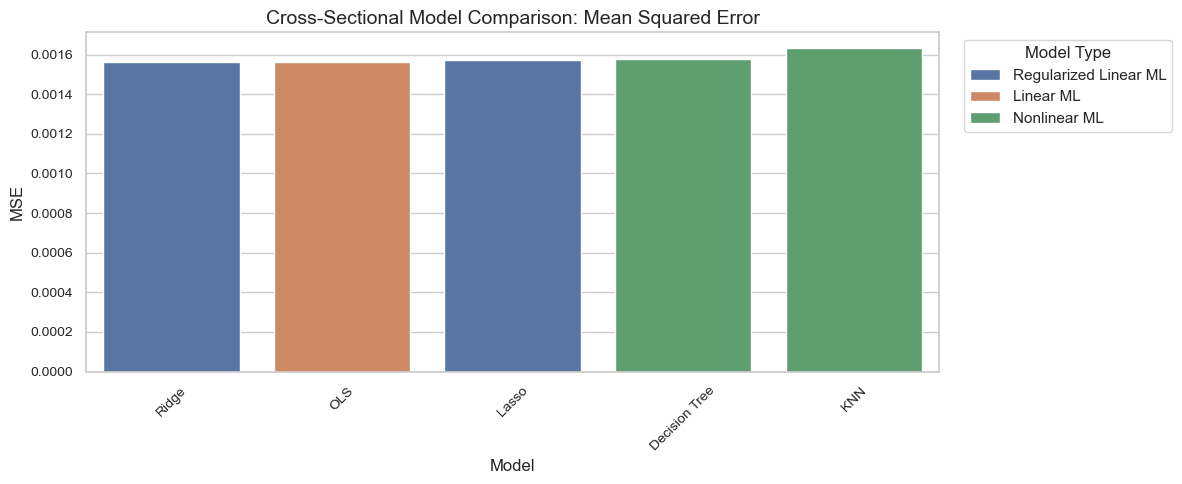

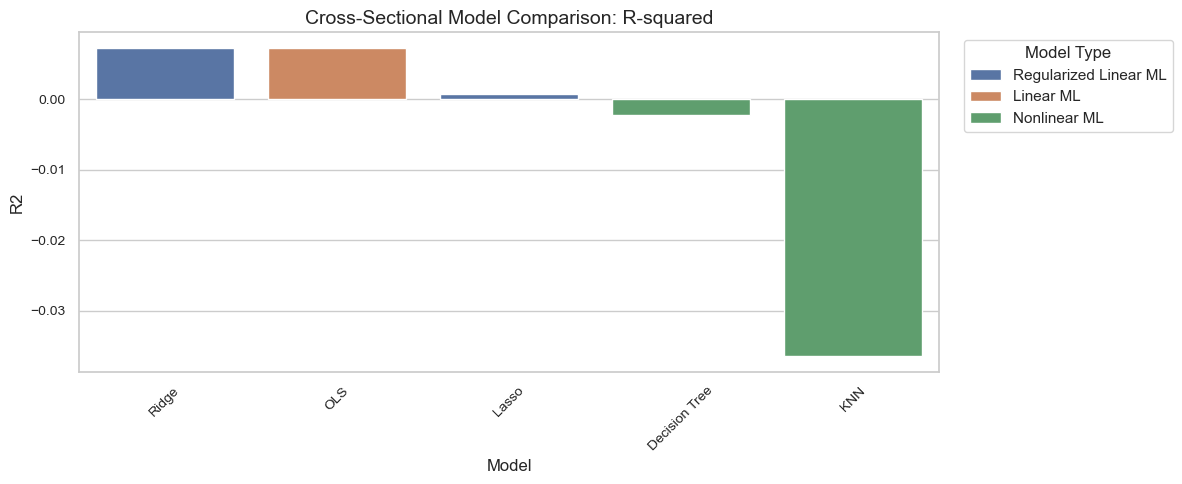

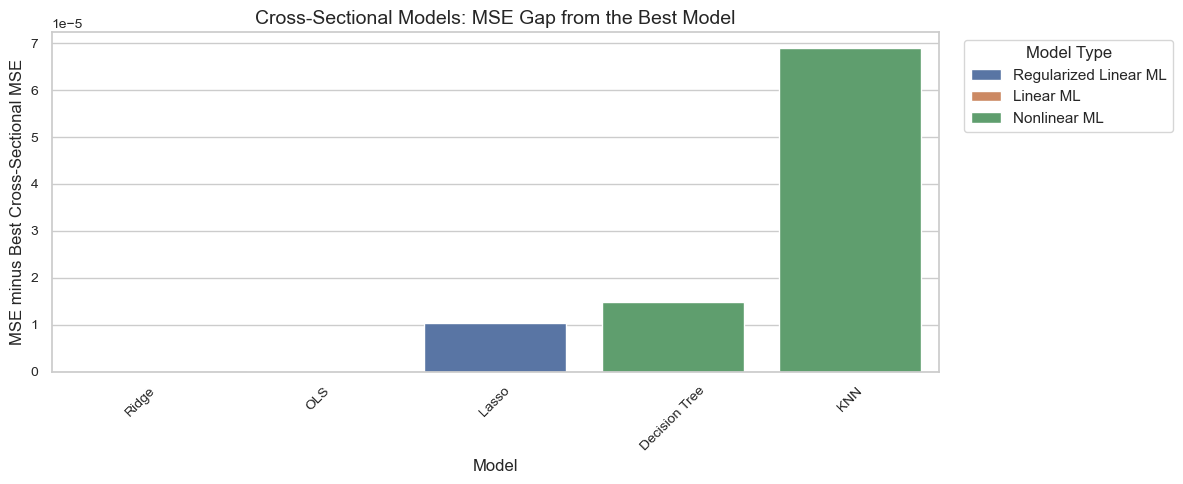

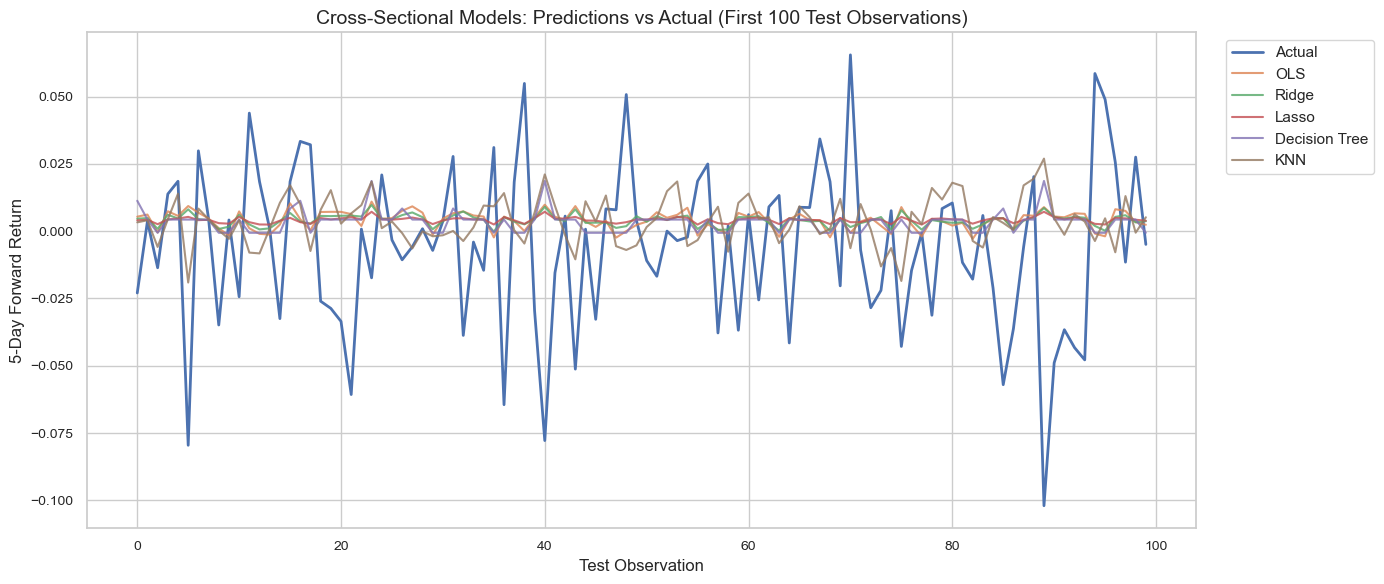

This unified section is important because OLS, Ridge, Lasso, Decision Tree, and KNN are all trained on the same features,evaluated on the same holdout period, and plotted in the same charts.


In [93]:
print("Training nonlinear machine learning models and comparing all cross-sectional models together")

# -------------------------------
# Decision Tree
# -------------------------------
# A decision tree can capture nonlinear feature interactions without requiring any manual transformation of the predictors.
tree_param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [20, 50, 100],
    "min_samples_leaf": [10, 25, 50]
}

tree_grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_grid=tree_param_grid,
    scoring="neg_mean_squared_error",
    cv=TimeSeriesSplit(n_splits=5),
    n_jobs=-1
)

tree_grid.fit(X_train, y_train)
tree_model = tree_grid.best_estimator_
tree_preds = tree_model.predict(X_test)

tree_mse = mean_squared_error(y_test, tree_preds)
tree_r2 = r2_score(y_test, tree_preds)

print("Best Decision Tree parameters:", tree_grid.best_params_)
print("Decision Tree MSE:", tree_mse)
print("Decision Tree R²:", tree_r2)

# -------------------------------
# K-Nearest Neighbors Regressor
# -------------------------------
# KNN predicts each observation using the average target value of the nearest
# observations in feature space. Because distance matters, scaled features are used.
knn_param_grid = {
    "n_neighbors": [5, 10, 20, 30],
    "weights": ["uniform", "distance"]
}

knn_grid = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=knn_param_grid,
    scoring="neg_mean_squared_error",
    cv=TimeSeriesSplit(n_splits=5),
    n_jobs=-1
)

knn_grid.fit(X_train_scaled, y_train)
knn_model = knn_grid.best_estimator_
knn_preds = knn_model.predict(X_test_scaled)

knn_mse = mean_squared_error(y_test, knn_preds)
knn_r2 = r2_score(y_test, knn_preds)

print("Best KNN parameters:", knn_grid.best_params_)
print("KNN MSE:", knn_mse)
print("KNN R²:", knn_r2)

# -------------------------------
# Unified cross-sectional comparison
# -------------------------------
# Now that all row-level supervised learning models have been trained, compare
# them together in one section using the same target, same test period, and
# same evaluation metrics.
cross_sectional_results = pd.DataFrame({
    "Model": ["OLS", "Ridge", "Lasso", "Decision Tree", "KNN"],
    "Model_Type": [
        "Linear ML", "Regularized Linear ML", "Regularized Linear ML",
        "Nonlinear ML", "Nonlinear ML"
    ],
    "MSE": [ols_mse, ridge_mse, lasso_mse, tree_mse, knn_mse],
    "R2": [ols_r2, ridge_r2, lasso_r2, tree_r2, knn_r2]
})

# Lower MSE is better; higher R² is better.
cross_sectional_results["MSE_Rank"] = cross_sectional_results["MSE"].rank(method="dense").astype(int)
cross_sectional_results["R2_Rank"] = cross_sectional_results["R2"].rank(ascending=False, method="dense").astype(int)

best_cross_mse = cross_sectional_results["MSE"].min()
best_cross_r2 = cross_sectional_results["R2"].max()
cross_sectional_results["MSE_vs_Best"] = cross_sectional_results["MSE"] - best_cross_mse
cross_sectional_results["R2_vs_Best"] = best_cross_r2 - cross_sectional_results["R2"]

cross_sectional_results = cross_sectional_results.sort_values(["MSE", "R2"], ascending=[True, False]).reset_index(drop=True)

print("\nComparison of all cross-sectional models:")
print(cross_sectional_results)

best_cross_model = cross_sectional_results.iloc[0]["Model"]
print(f"\nBest cross-sectional model by MSE: {best_cross_model}")

# Store the predictions in one place so they can be plotted together.
cross_sectional_predictions = {
    "Actual": y_test.reset_index(drop=True),
    "OLS": pd.Series(ols_preds),
    "Ridge": pd.Series(ridge_preds),
    "Lasso": pd.Series(lasso_preds),
    "Decision Tree": pd.Series(tree_preds),
    "KNN": pd.Series(knn_preds)
}

# -------------------------------
# Visualization 1: cross-sectional MSE comparison
# -------------------------------
plt.figure(figsize=(12, 5))
sns.barplot(data=cross_sectional_results, x="Model", y="MSE", hue="Model_Type", dodge=False)
plt.title("Cross-Sectional Model Comparison: Mean Squared Error")
plt.xticks(rotation=45)
plt.legend(title="Model Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# -------------------------------
# Visualization 2: cross-sectional R² comparison
# -------------------------------
plt.figure(figsize=(12, 5))
sns.barplot(data=cross_sectional_results, x="Model", y="R2", hue="Model_Type", dodge=False)
plt.title("Cross-Sectional Model Comparison: R-squared")
plt.xticks(rotation=45)
plt.legend(title="Model Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# -------------------------------
# Visualization 3: distance from the best cross-sectional model
# -------------------------------
plt.figure(figsize=(12, 5))
sns.barplot(data=cross_sectional_results, x="Model", y="MSE_vs_Best", hue="Model_Type", dodge=False)
plt.title("Cross-Sectional Models: MSE Gap from the Best Model")
plt.ylabel("MSE minus Best Cross-Sectional MSE")
plt.xticks(rotation=45)
plt.legend(title="Model Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# -------------------------------
# Visualization 4: actual vs predicted values for the first 100 test observations
# -------------------------------
comparison_plot_df = pd.DataFrame(cross_sectional_predictions).iloc[:100]

plt.figure(figsize=(14, 6))
plt.plot(comparison_plot_df.index, comparison_plot_df["Actual"], label="Actual", linewidth=2)
plt.plot(comparison_plot_df.index, comparison_plot_df["OLS"], label="OLS", alpha=0.8)
plt.plot(comparison_plot_df.index, comparison_plot_df["Ridge"], label="Ridge", alpha=0.8)
plt.plot(comparison_plot_df.index, comparison_plot_df["Lasso"], label="Lasso", alpha=0.8)
plt.plot(comparison_plot_df.index, comparison_plot_df["Decision Tree"], label="Decision Tree", alpha=0.8)
plt.plot(comparison_plot_df.index, comparison_plot_df["KNN"], label="KNN", alpha=0.8)
plt.title("Cross-Sectional Models: Predictions vs Actual (First 100 Test Observations)")
plt.xlabel("Test Observation")
plt.ylabel("5-Day Forward Return")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print(
    "This unified section is important because OLS, Ridge, Lasso, Decision Tree, and KNN "
    "are all trained on the same features,evaluated on the same holdout period, and plotted in the same charts."
)


In [94]:
print("Building ARIMA and SARIMA benchmarks on an equal-weighted market series")

# ARIMA and SARIMA are univariate time-series models, so they cannot directly use the full panel of cross-sectional predictors used above.
# To include them meaningfully in this project, we create an equal-weighted average 5-day forward return series across all tickers by date.
# This gives us a portfolio-level forecasting benchmark.

portfolio_series = (
    data.groupby("Date")["target_5d"]
    .mean()
    .sort_index()
)

portfolio_train = portfolio_series[portfolio_series.index < pd.to_datetime(split_date)]
portfolio_test = portfolio_series[portfolio_series.index >= pd.to_datetime(split_date)]

print("Portfolio train observations:", len(portfolio_train))
print("Portfolio test observations:", len(portfolio_test))

# -------------------------------
# ARIMA MODEL
# -------------------------------
# ARIMA(1,0,1) is used as a simple baseline:
# - 1 autoregressive lag
# - 0 differences because returns are usually already close to stationary
# - 1 moving average lag
arima_model = ARIMA(portfolio_train, order=(1, 0, 1))
arima_fit = arima_model.fit()
arima_preds = arima_fit.forecast(steps=len(portfolio_test))

arima_mse = mean_squared_error(portfolio_test, arima_preds)
arima_r2 = r2_score(portfolio_test, arima_preds)

print("ARIMA MSE:", arima_mse)
print("ARIMA R²:", arima_r2)

# -------------------------------
# SARIMA MODEL
# -------------------------------
# A seasonal period of 5 is used to roughly reflect the weekly rhythm of
# trading days in financial markets.
sarima_model = SARIMAX(
    portfolio_train,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 5),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)
sarima_preds = sarima_fit.forecast(steps=len(portfolio_test))

sarima_mse = mean_squared_error(portfolio_test, sarima_preds)
sarima_r2 = r2_score(portfolio_test, sarima_preds)

print("SARIMA MSE:", sarima_mse)
print("SARIMA R²:", sarima_r2)

# Compare the time-series models with the panel-data supervised models carefully.
# They are not trained on identical information, but they still provide a useful
# benchmark for whether simple time dependence alone is competitive.
best_panel_mse_so_far = min(ols_mse, ridge_mse, lasso_mse, tree_mse, knn_mse)
print("\nTime-series benchmark vs. best panel-data model:")
print(f"ARIMA MSE difference vs best panel-data model: {arima_mse - best_panel_mse_so_far:.6f}")
print(f"SARIMA MSE difference vs best panel-data model: {sarima_mse - best_panel_mse_so_far:.6f}")


Building ARIMA and SARIMA benchmarks on an equal-weighted market series
Portfolio train observations: 482
Portfolio test observations: 244
ARIMA MSE: 0.0004880812621586703
ARIMA R²: -8.462726305968893e-05
SARIMA MSE: 0.0005063742159844788
SARIMA R²: -0.03756711906680499

Time-series benchmark vs. best panel-data model:
ARIMA MSE difference vs best panel-data model: -0.001074
SARIMA MSE difference vs best panel-data model: -0.001056


Creating a full head-to-head comparison across all models
           Model       MSE        R2             Model_Type  MSE_Rank  \
0          ARIMA  0.000488 -0.000085            Time Series         1   
1         SARIMA  0.000506 -0.037567            Time Series         2   
2          Ridge  0.001562  0.007319  Regularized Linear ML         3   
3            OLS  0.001562  0.007249              Linear ML         4   
4          Lasso  0.001572  0.000770  Regularized Linear ML         5   
5  Decision Tree  0.001577 -0.002163           Nonlinear ML         6   
6            KNN  0.001631 -0.036459           Nonlinear ML         7   

   R2_Rank  MSE_vs_Best  R2_vs_Best  
0        4     0.000000    0.007403  
1        7     0.000018    0.044886  
2        1     0.001074    0.000000  
3        2     0.001074    0.000069  
4        3     0.001084    0.006549  
5        5     0.001089    0.009482  
6        6     0.001143    0.043778  

Best overall model by MSE: ARIMA
Runner-up model by 

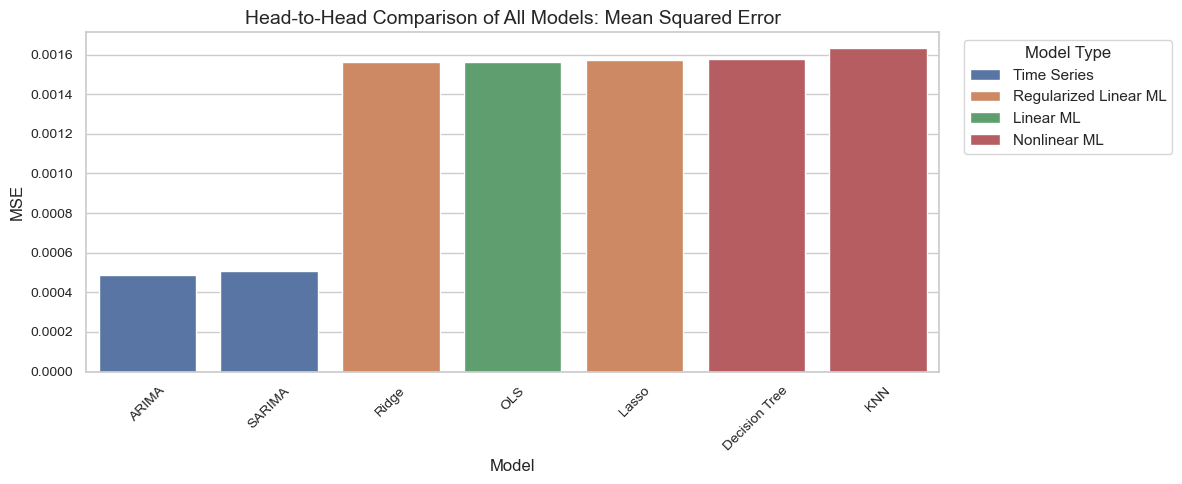

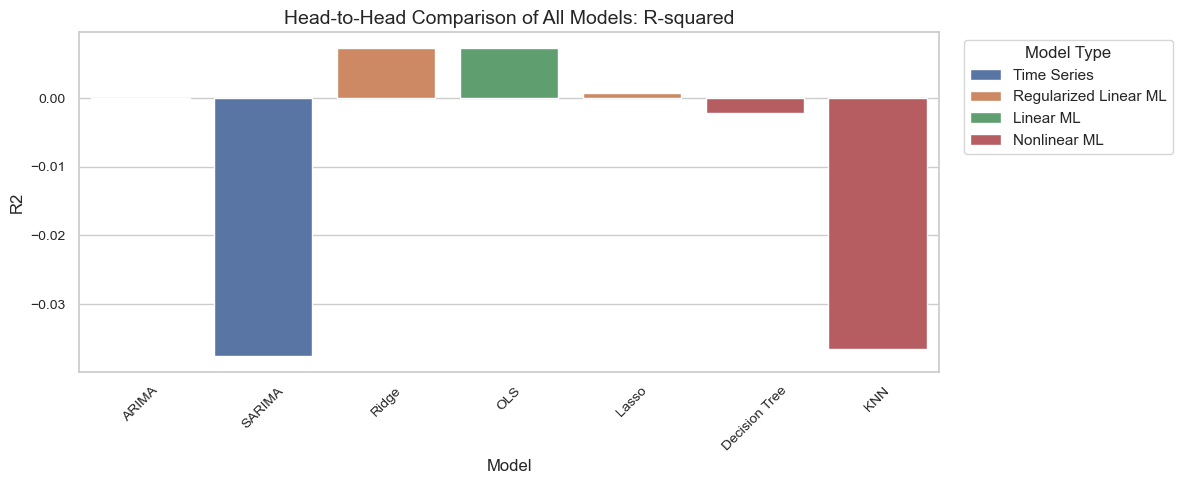

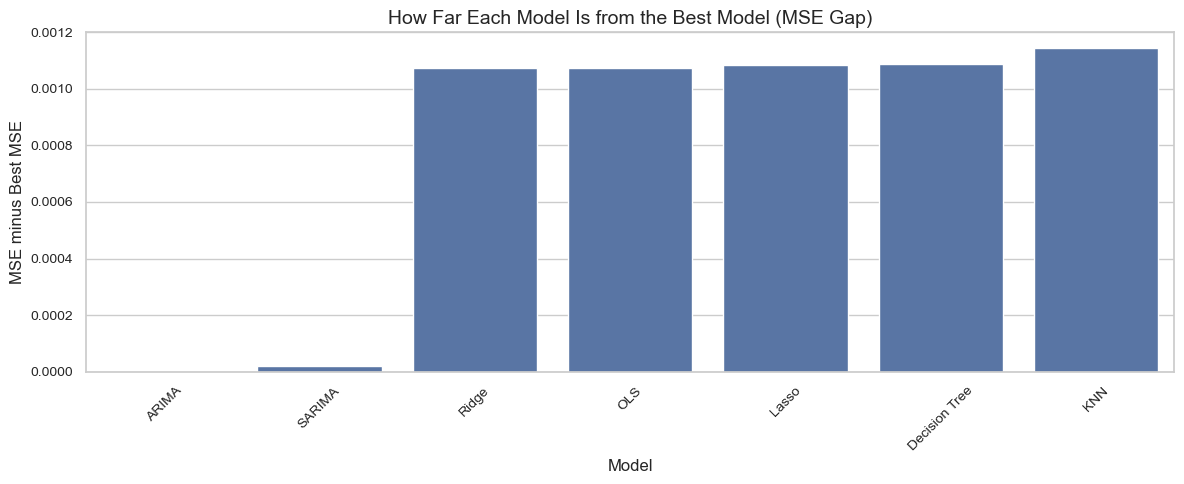

In [95]:
print("Creating a full head-to-head comparison across all models")

# Combine every model into one table so the notebook reads as a direct
# competition among alternative approaches rather than a sequence of isolated fits.
model_results = pd.DataFrame({
    "Model": ["OLS", "Ridge", "Lasso", "Decision Tree", "KNN", "ARIMA", "SARIMA"],
    "MSE": [ols_mse, ridge_mse, lasso_mse, tree_mse, knn_mse, arima_mse, sarima_mse],
    "R2": [ols_r2, ridge_r2, lasso_r2, tree_r2, knn_r2, arima_r2, sarima_r2],
    "Model_Type": [
        "Linear ML", "Regularized Linear ML", "Regularized Linear ML",
        "Nonlinear ML", "Nonlinear ML", "Time Series", "Time Series"
    ]
})

# Ranking columns make the comparison easier to explain in the final report.
model_results["MSE_Rank"] = model_results["MSE"].rank(method="dense").astype(int)
model_results["R2_Rank"] = model_results["R2"].rank(ascending=False, method="dense").astype(int)

# Create gap columns relative to the best-performing model.
best_mse = model_results["MSE"].min()
best_r2 = model_results["R2"].max()
model_results["MSE_vs_Best"] = model_results["MSE"] - best_mse
model_results["R2_vs_Best"] = best_r2 - model_results["R2"]

model_results = model_results.sort_values(["MSE", "R2"], ascending=[True, False]).reset_index(drop=True)
print(model_results)

best_model_name = model_results.iloc[0]["Model"]
runner_up_name = model_results.iloc[1]["Model"]
runner_up_gap = model_results.iloc[1]["MSE"] - model_results.iloc[0]["MSE"]

print(f"\nBest overall model by MSE: {best_model_name}")
print(f"Runner-up model by MSE: {runner_up_name}")
print(f"MSE gap between winner and runner-up: {runner_up_gap:.6f}")

# Summarize which modeling family performs best on average.
family_summary = (
    model_results.groupby("Model_Type")[["MSE", "R2"]]
    .mean()
    .sort_values("MSE")
    .reset_index()
)

print("\nAverage performance by model family:")
print(family_summary)

# -------------------------------
# Visualization 1: overall head-to-head MSE comparison
# -------------------------------
plt.figure(figsize=(12, 5))
sns.barplot(data=model_results, x="Model", y="MSE", hue="Model_Type", dodge=False)
plt.title("Head-to-Head Comparison of All Models: Mean Squared Error")
plt.xticks(rotation=45)
plt.legend(title="Model Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# -------------------------------
# Visualization 2: overall head-to-head R² comparison
# -------------------------------
plt.figure(figsize=(12, 5))
sns.barplot(data=model_results, x="Model", y="R2", hue="Model_Type", dodge=False)
plt.title("Head-to-Head Comparison of All Models: R-squared")
plt.xticks(rotation=45)
plt.legend(title="Model Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# -------------------------------
# Visualization 3: performance gap from the winner
# -------------------------------
plt.figure(figsize=(12, 5))
sns.barplot(data=model_results, x="Model", y="MSE_vs_Best")
plt.title("How Far Each Model Is from the Best Model (MSE Gap)")
plt.ylabel("MSE minus Best MSE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [96]:
print("Writing a direct comparison summary of all models")

# This section translates the metric table into report-ready interpretation.
comparison_summary = model_results[["Model", "Model_Type", "MSE", "R2", "MSE_Rank", "R2_Rank"]].copy()

best_overall = comparison_summary.iloc[0]
best_linear_row = model_results[model_results["Model_Type"].isin(["Linear ML", "Regularized Linear ML"])].sort_values("MSE").iloc[0]
best_nonlinear_row = model_results[model_results["Model_Type"] == "Nonlinear ML"].sort_values("MSE").iloc[0]
best_ts_row = model_results[model_results["Model_Type"] == "Time Series"].sort_values("MSE").iloc[0]

print("Best model within each family:")
print(f"- Best linear model: {best_linear_row['Model']} | MSE={best_linear_row['MSE']:.6f} | R²={best_linear_row['R2']:.6f}")
print(f"- Best nonlinear model: {best_nonlinear_row['Model']} | MSE={best_nonlinear_row['MSE']:.6f} | R²={best_nonlinear_row['R2']:.6f}")
print(f"- Best time-series model: {best_ts_row['Model']} | MSE={best_ts_row['MSE']:.6f} | R²={best_ts_row['R2']:.6f}")


print(
    f"The strongest overall model is {best_overall['Model']}, which ranked first on MSE. "
    f"Among linear models, {best_linear_row['Model']} performed best. "
    f"Among nonlinear models, {best_nonlinear_row['Model']} performed best. "
    f"Among pure time-series benchmarks, {best_ts_row['Model']} performed best."
)

if best_overall["Model"] == best_linear_row["Model"]:
    print("Interpretation: the engineered predictors appear to contain mostly modest linear signal, and extra model complexity did not outperform the strongest linear benchmark.")
elif best_overall["Model"] == best_nonlinear_row["Model"]:
    print("Interpretation: nonlinear structure appears to matter, suggesting interactions or threshold effects in the predictors that linear models miss.")
else:
    print("Interpretation: simple time dependence at the portfolio level was surprisingly competitive, suggesting persistence or weekly structure may be as informative as the cross-sectional feature set.")


Writing a direct comparison summary of all models
Best model within each family:
- Best linear model: Ridge | MSE=0.001562 | R²=0.007319
- Best nonlinear model: Decision Tree | MSE=0.001577 | R²=-0.002163
- Best time-series model: ARIMA | MSE=0.000488 | R²=-0.000085
The strongest overall model is ARIMA, which ranked first on MSE. Among linear models, Ridge performed best. Among nonlinear models, Decision Tree performed best. Among pure time-series benchmarks, ARIMA performed best.
Interpretation: simple time dependence at the portfolio level was surprisingly competitive, suggesting persistence or weekly structure may be as informative as the cross-sectional feature set.


Visualizing Decision Tree feature importance
         Feature  Importance
2        vol_10d    0.428706
9           beta    0.276254
5   momentum_10d    0.237486
3        vol_20d    0.057554
0      return_1d    0.000000
1      return_5d    0.000000
4       volume_z    0.000000
6       pe_ratio    0.000000
7     forward_pe    0.000000
8  price_to_book    0.000000


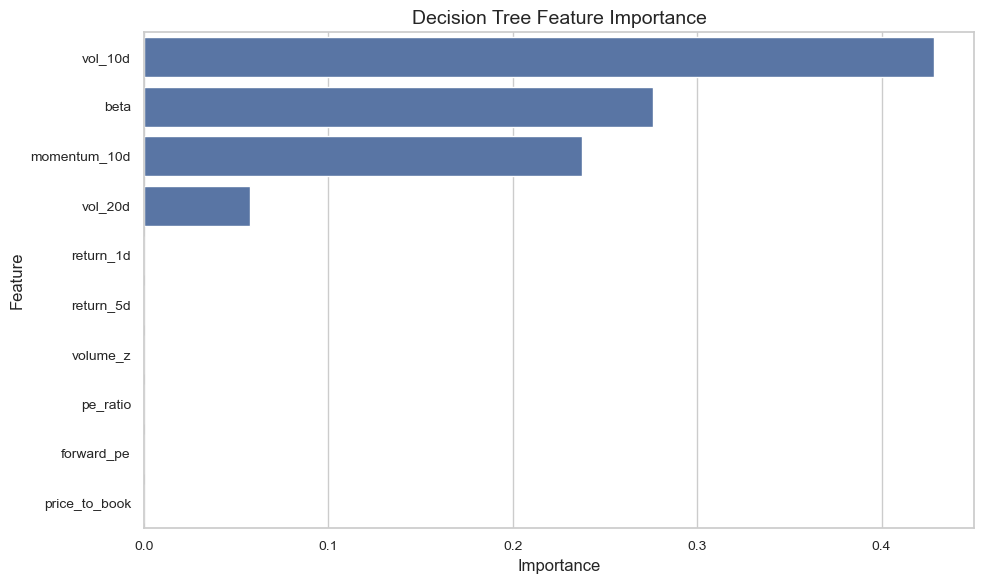

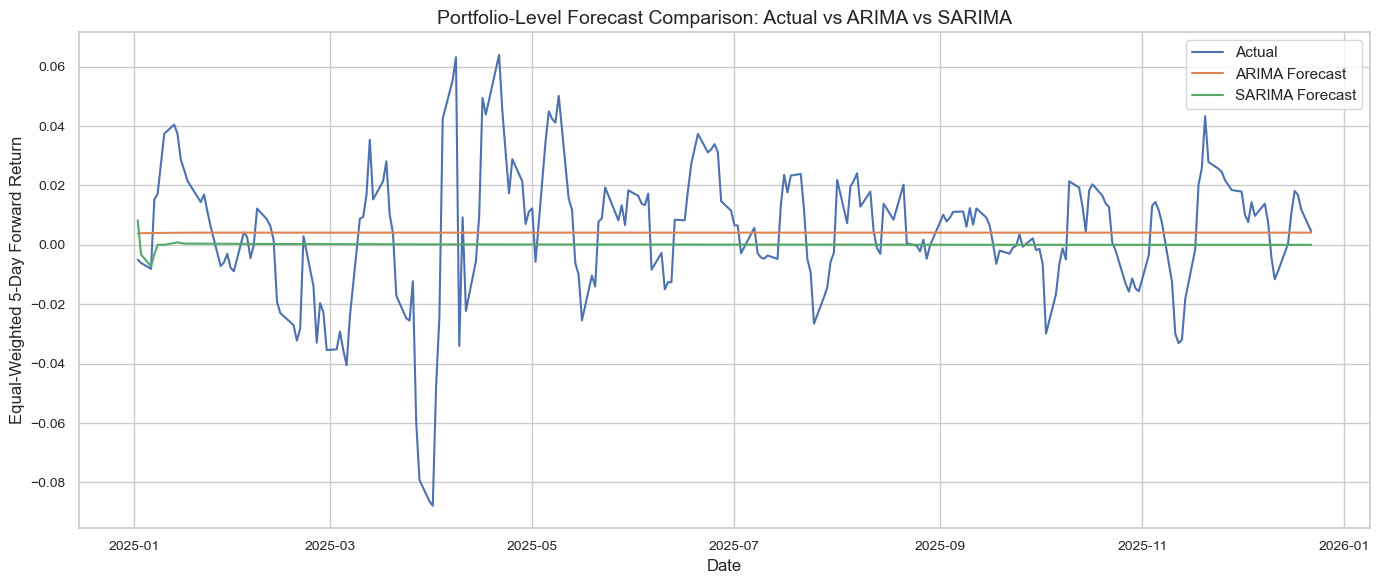

In [97]:
print("Visualizing Decision Tree feature importance")

# Tree-based models can provide a useful ranking of which variables
# contributed most to the model's split decisions.
tree_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": tree_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(tree_importance)

plt.figure(figsize=(10, 6))
sns.barplot(data=tree_importance, x="Importance", y="Feature")
plt.title("Decision Tree Feature Importance")
plt.tight_layout()
plt.show()

# Plot portfolio-level forecasts from ARIMA and SARIMA against the actual series.
forecast_df = pd.DataFrame({
    "Actual": portfolio_test.values,
    "ARIMA Forecast": np.asarray(arima_preds),
    "SARIMA Forecast": np.asarray(sarima_preds)
}, index=portfolio_test.index)

plt.figure(figsize=(14, 6))
plt.plot(forecast_df.index, forecast_df["Actual"], label="Actual")
plt.plot(forecast_df.index, forecast_df["ARIMA Forecast"], label="ARIMA Forecast")
plt.plot(forecast_df.index, forecast_df["SARIMA Forecast"], label="SARIMA Forecast")
plt.title("Portfolio-Level Forecast Comparison: Actual vs ARIMA vs SARIMA")
plt.xlabel("Date")
plt.ylabel("Equal-Weighted 5-Day Forward Return")
plt.legend()
plt.tight_layout()
plt.show()
